# NASA Airfoil Self-Noise Analysis

This notebook focuses on frequency-band interpretation of SSPL.
The frequency column `f` is treated as the spectral axis, while
`alpha`, `c`, `U_infinity`, and `delta` are treated as operating/design variables.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('AirfoilSelfNoise.csv')


## 1. Data Overview


In [51]:
display(df.head(14))
print()
df.info()
print()
display(df.describe())
print()
print("Missing values")
display(df.isna().sum().to_frame(name='missing_count'))


,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB



,f,alpha,c,U_infinity,delta,SSPL
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000



Missing values


,missing_count
f,0
alpha,0
c,0
U_infinity,0
delta,0
SSPL,0


## 2. Derived Variables and Group Definitions

Frequency is grouped into four bands for spectral interpretation.
`alpha` is grouped by interpretable angle ranges, and `delta` is converted
from meters to millimeters before grouping.


In [52]:
condition_cols = ['alpha', 'c', 'U_infinity', 'delta']

frequency_band_labels = [
    'Low (<=1 kHz)',
    'Low-Mid (1-4 kHz)',
    'Mid-High (4-8 kHz)',
    'High (>8 kHz)'
]
frequency_band_edges = [0, 1000, 4000, 8000, np.inf]

df['frequency_band'] = pd.cut(
    df['f'],
    bins=frequency_band_edges,
    labels=frequency_band_labels,
    include_lowest=True,
    right=True
)

alpha_group_labels = [
    '0-<4 deg',
    '4-<8 deg',
    '8-<12 deg',
    '>=12 deg'
]
df['alpha_group'] = pd.cut(
    df['alpha'],
    bins=[-0.001, 4, 8, 12, np.inf],
    labels=alpha_group_labels,
    right=False
)

df['delta_mm'] = df['delta'] * 1000
delta_group_labels = [
    '<=2 mm',
    '2-5 mm',
    '5-10 mm',
    '10-20 mm',
    '>20 mm'
]
df['delta_group'] = pd.cut(
    df['delta_mm'],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=delta_group_labels,
    include_lowest=True,
    right=True
)

df['condition_id'] = df[condition_cols].astype(str).agg(' | '.join, axis=1)

print("Alpha group counts")
display(df['alpha_group'].value_counts(sort=False).to_frame(name='sample_count'))
print()
print("Delta group counts")
display(df['delta_group'].value_counts(sort=False).to_frame(name='sample_count'))


Alpha group counts


,sample_count
alpha_group,
0-<4 deg,555
4-<8 deg,379
8-<12 deg,223
>=12 deg,346



Delta group counts


,sample_count
delta_group,
<=2 mm,266
2-5 mm,515
5-10 mm,188
10-20 mm,237
>20 mm,297


## 3. Linear Correlation Among Operating/Design Variables

`f` is excluded from this matrix because it is the spectral axis.
This correlation matrix is used only to summarize linear relationships.


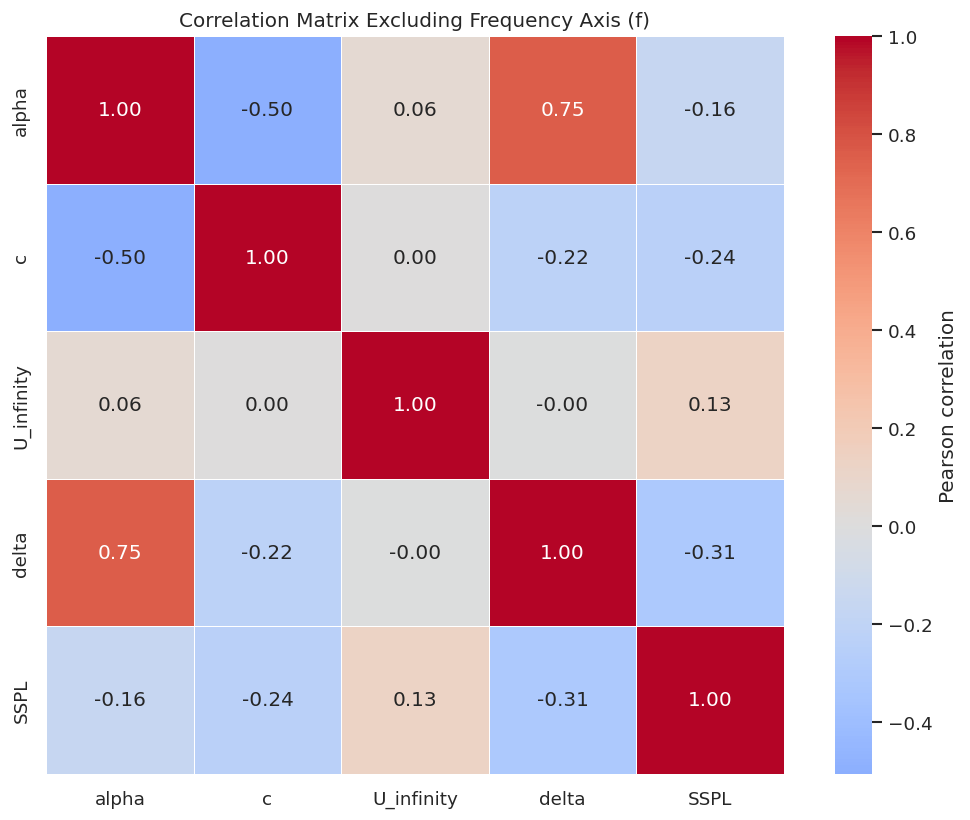

In [53]:
corr_cols = ['alpha', 'c', 'U_infinity', 'delta', 'SSPL']
corr_matrix = df[corr_cols].corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson correlation'}
)
plt.title('Correlation Matrix Excluding Frequency Axis (f)')
plt.tight_layout()
plt.show()


## 4. Frequency-Band Summary


In [54]:
band_summary = (
    df.groupby('frequency_band', observed=False)
    .agg(
        sample_count=('SSPL', 'size'),
        measured_frequency_points=('f', 'nunique'),
        mean_SSPL=('SSPL', 'mean'),
        median_SSPL=('SSPL', 'median'),
        max_SSPL=('SSPL', 'max')
    )
    .reset_index()
)

print("Frequency-band summary")
display(band_summary)
print()
print("Unique operating conditions:", df['condition_id'].nunique())
print("Frequencies per operating condition")
display(
    df.groupby(condition_cols)['f']
    .nunique()
    .describe()
    .to_frame(name='measured_frequency_points')
)


Frequency-band summary


,frequency_band,sample_count,measured_frequency_points,mean_SSPL,median_SSPL,max_SSPL
0,Low (<=1 kHz),564,8,127.191718,127.657,140.158
1,Low-Mid (1-4 kHz),617,6,125.287439,125.724,140.987
2,Mid-High (4-8 kHz),236,3,120.316309,118.884,138.607
3,High (>8 kHz),86,4,118.549930,117.090,134.563



Unique operating conditions: 106
Frequencies per operating condition


,measured_frequency_points
count,106.000000
mean,14.179245
std,2.215947
min,8.000000
25%,13.000000
50%,14.000000
75%,16.000000
max,19.000000


## 5. Overall Spectrum and Band Distribution


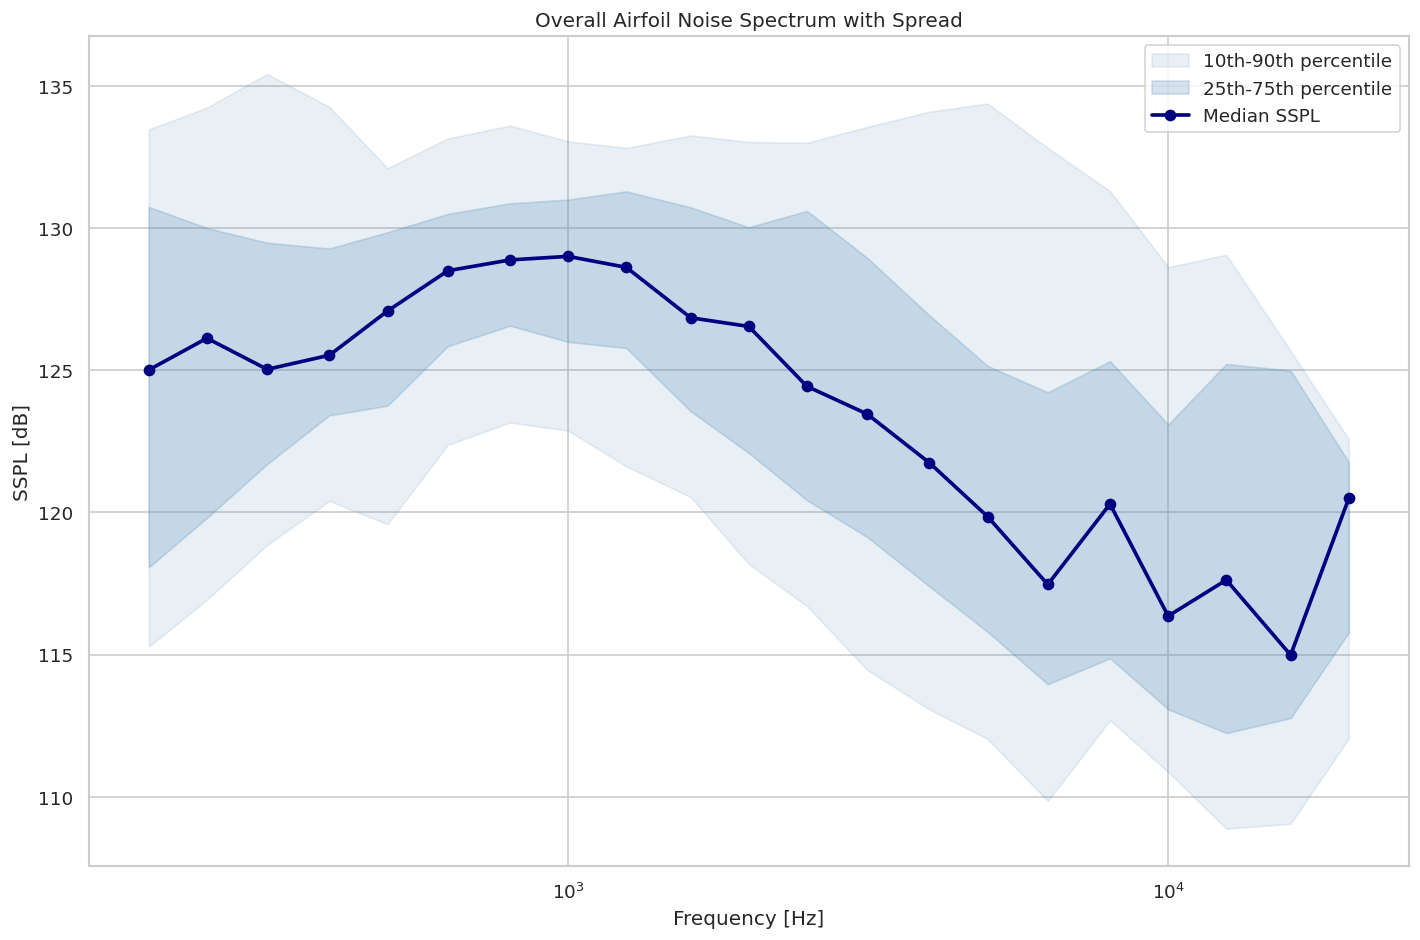

In [55]:
spectrum_summary = (
    df.groupby('f')
    .agg(
        mean_SSPL=('SSPL', 'mean'),
        median_SSPL=('SSPL', 'median'),
        q10_SSPL=('SSPL', lambda s: s.quantile(0.10)),
        q25_SSPL=('SSPL', lambda s: s.quantile(0.25)),
        q75_SSPL=('SSPL', lambda s: s.quantile(0.75)),
        q90_SSPL=('SSPL', lambda s: s.quantile(0.90))
    )
    .reset_index()
)

plt.figure(figsize=(12, 8))
plt.fill_between(
    spectrum_summary['f'],
    spectrum_summary['q10_SSPL'],
    spectrum_summary['q90_SSPL'],
    color='steelblue',
    alpha=0.12,
    label='10th-90th percentile'
)
plt.fill_between(
    spectrum_summary['f'],
    spectrum_summary['q25_SSPL'],
    spectrum_summary['q75_SSPL'],
    color='steelblue',
    alpha=0.22,
    label='25th-75th percentile'
)
plt.plot(
    spectrum_summary['f'],
    spectrum_summary['median_SSPL'],
    color='navy',
    linewidth=2.2,
    marker='o',
    label='Median SSPL'
)
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('SSPL [dB]')
plt.title('Overall Airfoil Noise Spectrum with Spread')
plt.legend()
plt.tight_layout()
plt.show()


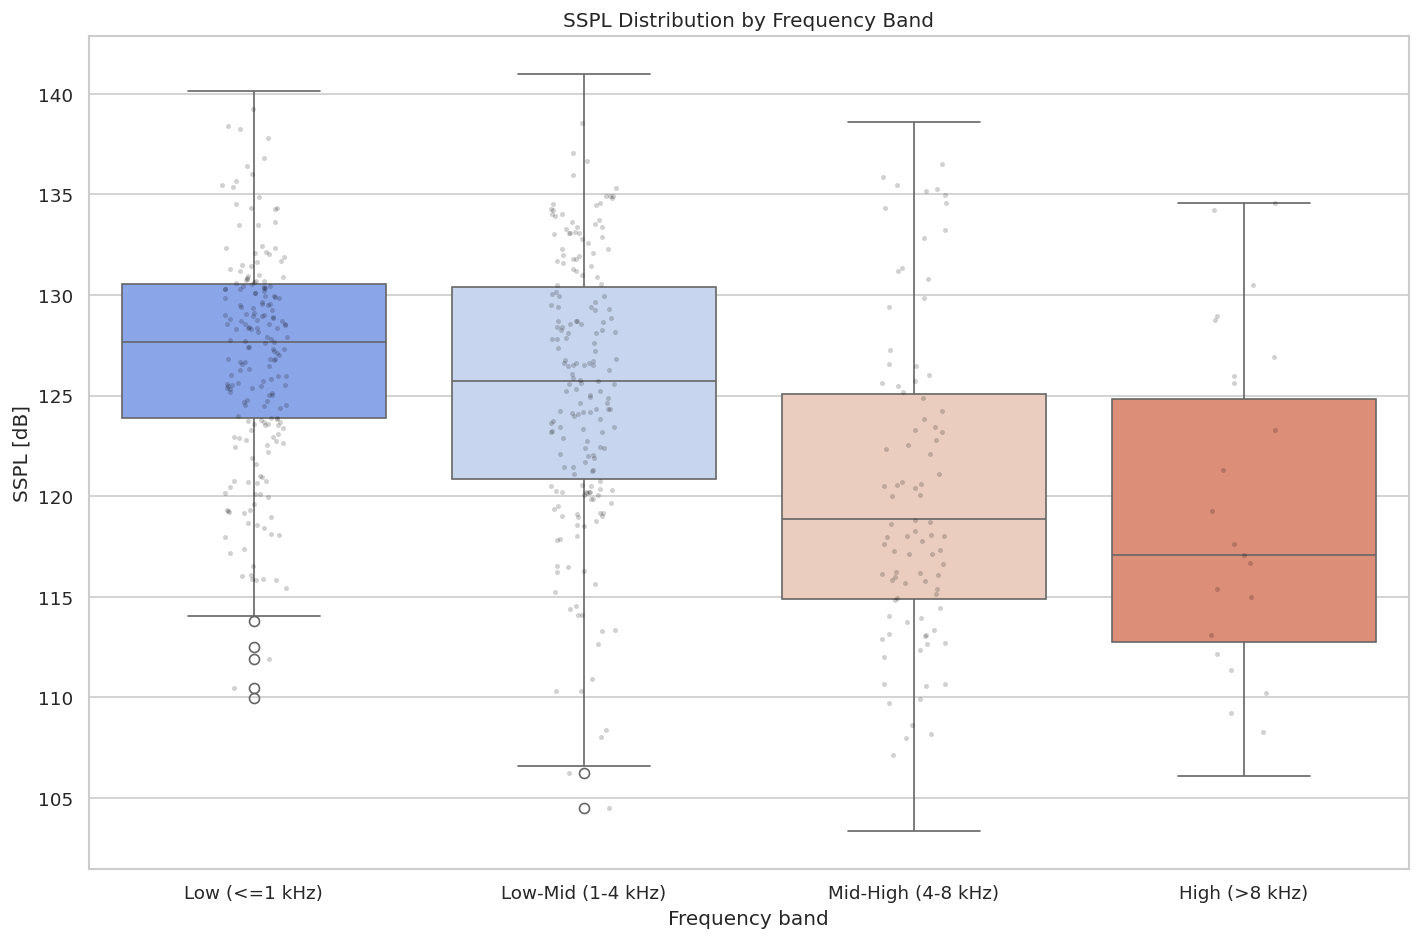

In [56]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    x='frequency_band',
    y='SSPL',
    hue='frequency_band',
    dodge=False,
    palette='coolwarm',
    legend=False
)

sns.stripplot(
    data=df.sample(n=min(500, len(df)), random_state=42),
    x='frequency_band',
    y='SSPL',
    color='black',
    alpha=0.18,
    size=3
)

plt.xlabel('Frequency band')
plt.ylabel('SSPL [dB]')
plt.title('SSPL Distribution by Frequency Band')
plt.tight_layout()
plt.show()


## 6. Parameter-wise Spectrum and Relative Band Emphasis

Relative band emphasis is defined as:

`band mean SSPL - row mean SSPL`

A positive value means that the band is stronger than the average
spectrum for that specific operating/design condition.


In [57]:
def plot_median_spectrum(data, group_col, title, palette='coolwarm'):
    spectrum = (
        data.groupby([group_col, 'f'], observed=False)['SSPL']
        .median()
        .reset_index()
    )

    plt.figure(figsize=(12, 8))
    sns.lineplot(
        data=spectrum,
        x='f',
        y='SSPL',
        hue=group_col,
        marker='o',
        palette=palette
    )
    plt.xscale('log')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Median SSPL [dB]')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_relative_band_heatmap(data, index_col, ylabel, title, figsize=(10, 6)):
    band_mean = (
        data.pivot_table(
            index=index_col,
            columns='frequency_band',
            values='SSPL',
            aggfunc='mean',
            observed=False
        )
        .reindex(columns=frequency_band_labels)
    )

    band_relative = band_mean.sub(band_mean.mean(axis=1), axis=0)

    plt.figure(figsize=figsize)
    sns.heatmap(
        band_relative,
        annot=True,
        fmt='.1f',
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Band mean - row mean [dB]'}
    )
    plt.xlabel('Frequency band')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


### 6.1 Flow Speed (`U_infinity`)


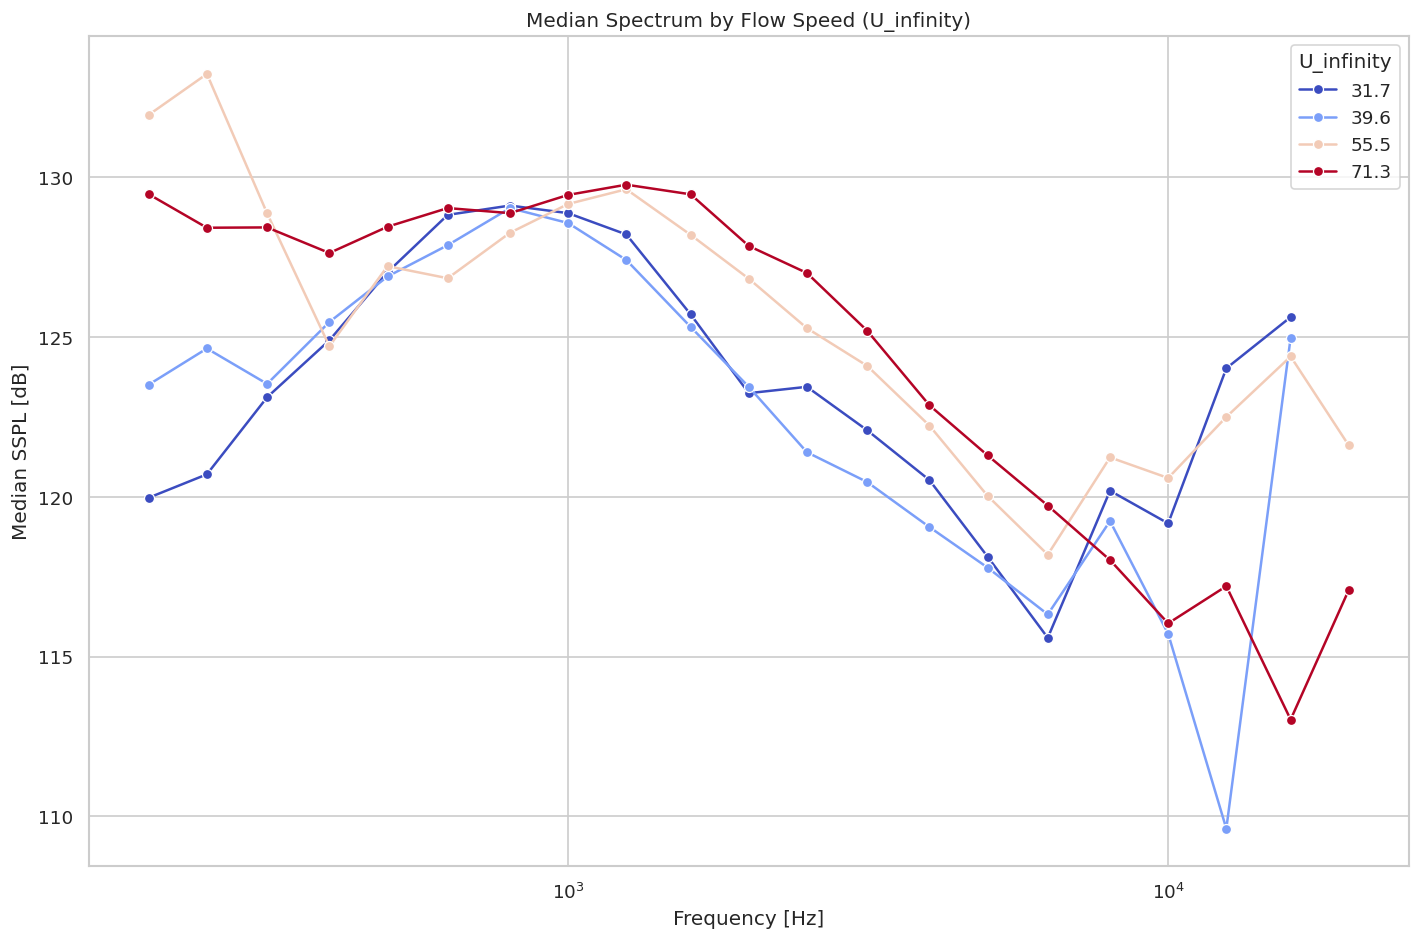

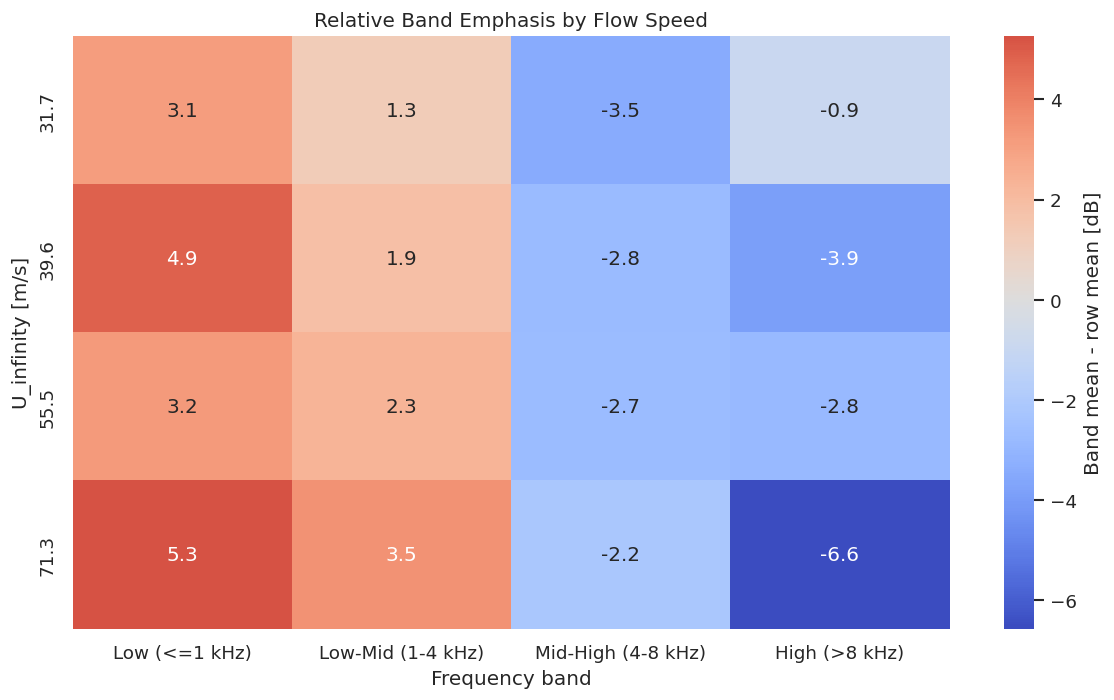

In [58]:
plot_median_spectrum(
    df,
    group_col='U_infinity',
    title='Median Spectrum by Flow Speed (U_infinity)'
)

plot_relative_band_heatmap(
    df,
    index_col='U_infinity',
    ylabel='U_infinity [m/s]',
    title='Relative Band Emphasis by Flow Speed'
)


### 6.2 Chord Length (`c`)


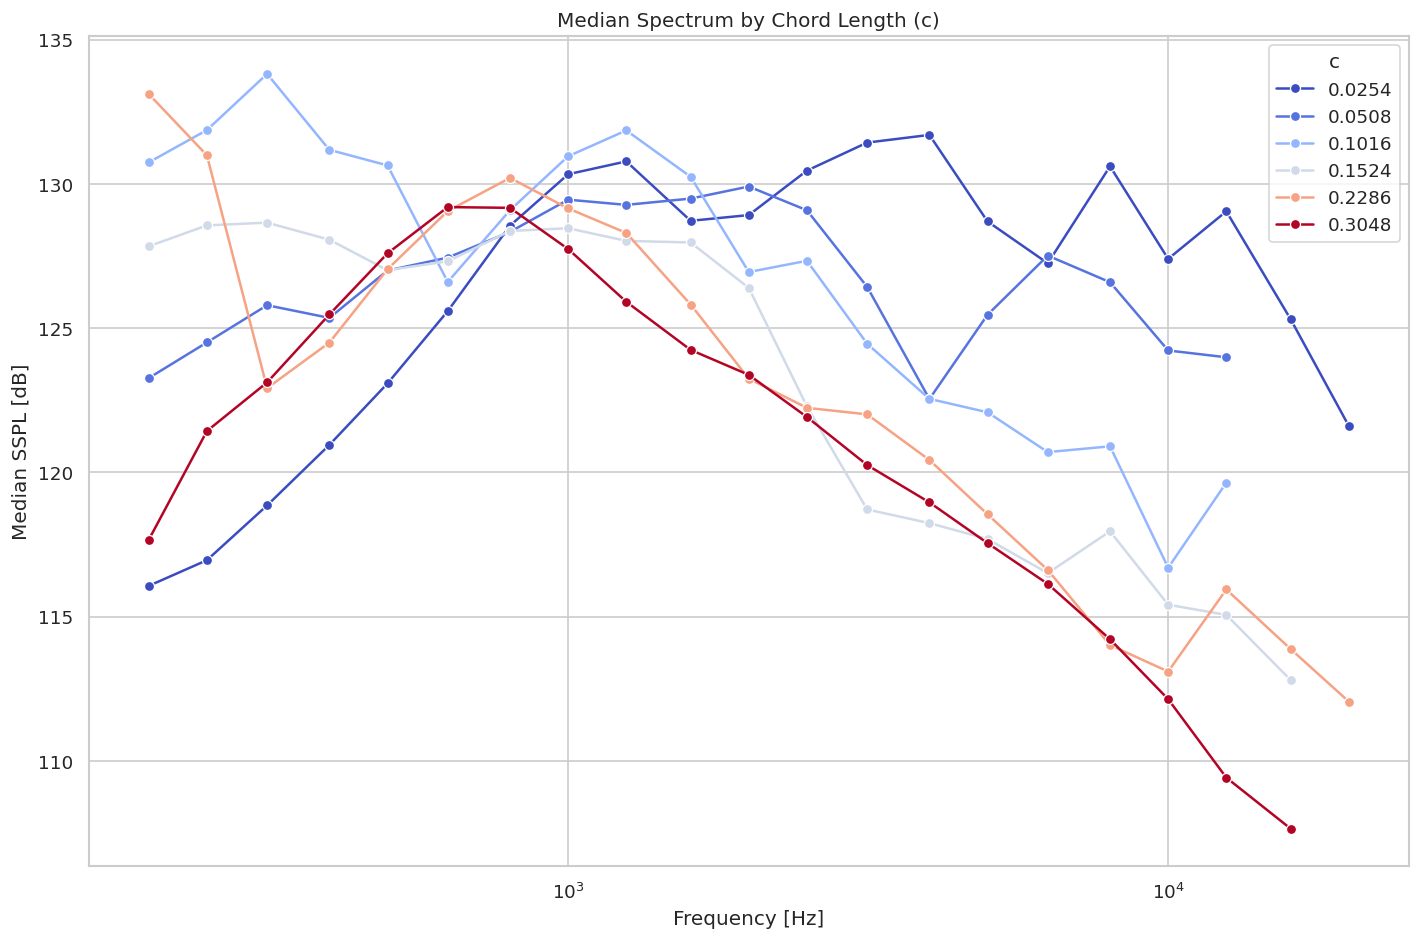

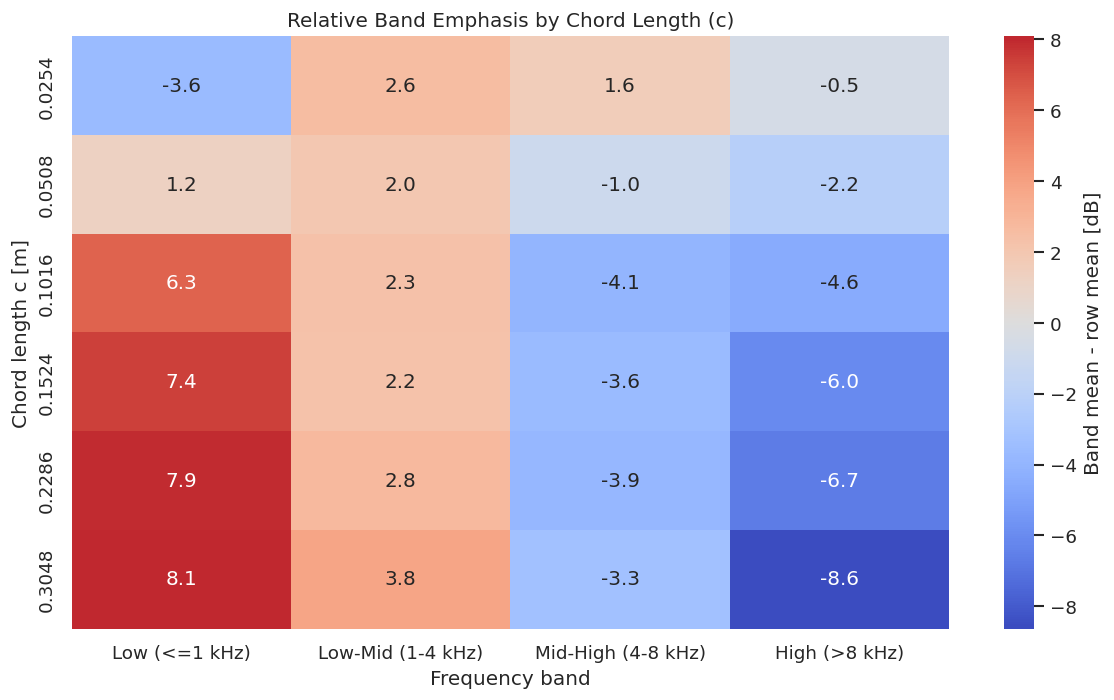

In [59]:
plot_median_spectrum(
    df,
    group_col='c',
    title='Median Spectrum by Chord Length (c)'
)

plot_relative_band_heatmap(
    df,
    index_col='c',
    ylabel='Chord length c [m]',
    title='Relative Band Emphasis by Chord Length (c)'
)


### 6.3 Angle of Attack (`alpha`)


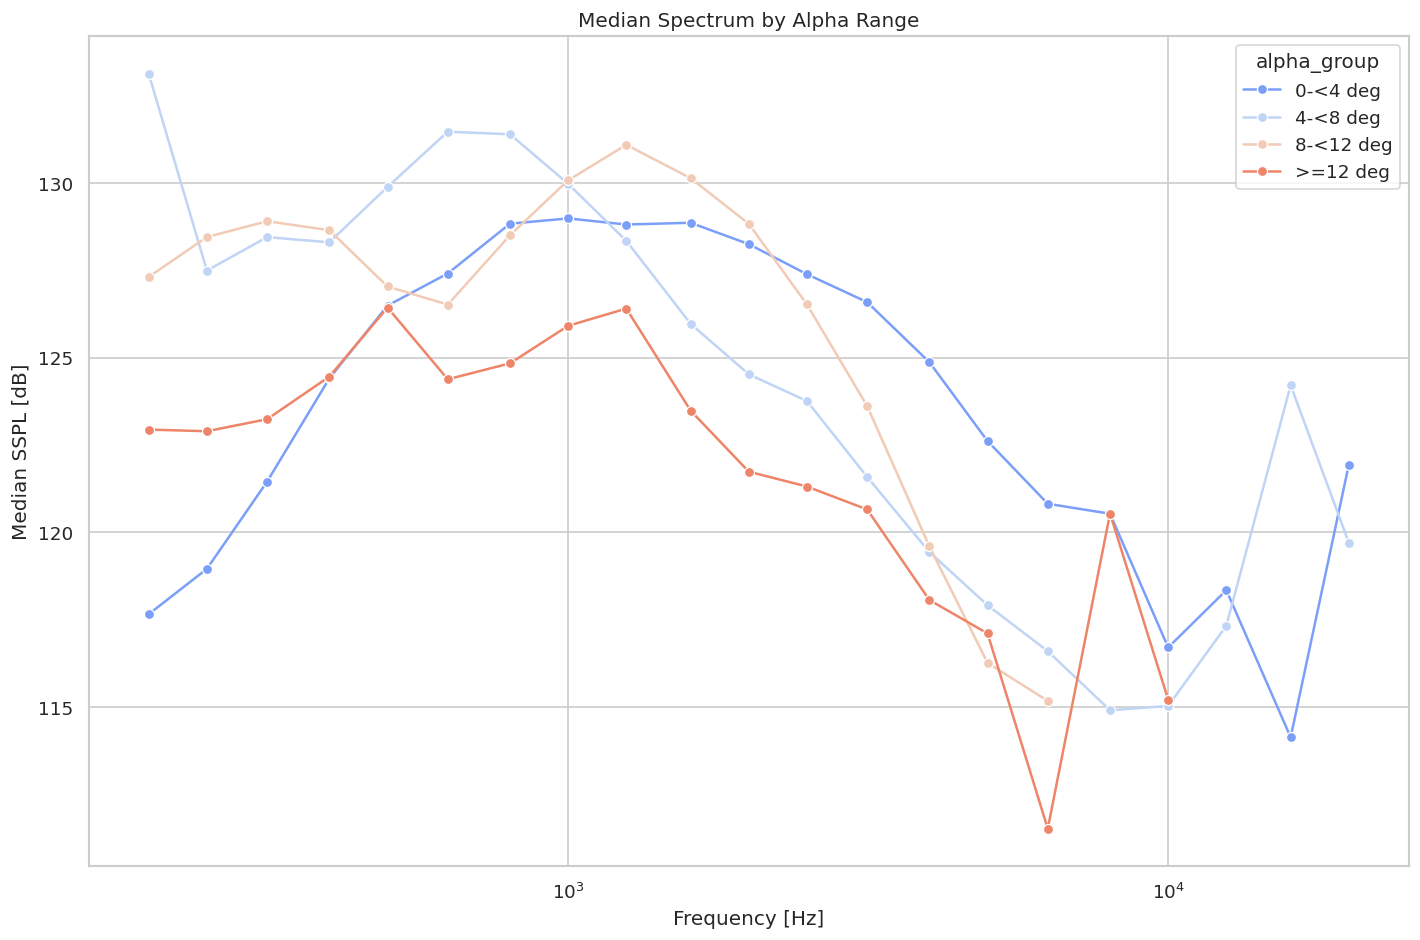

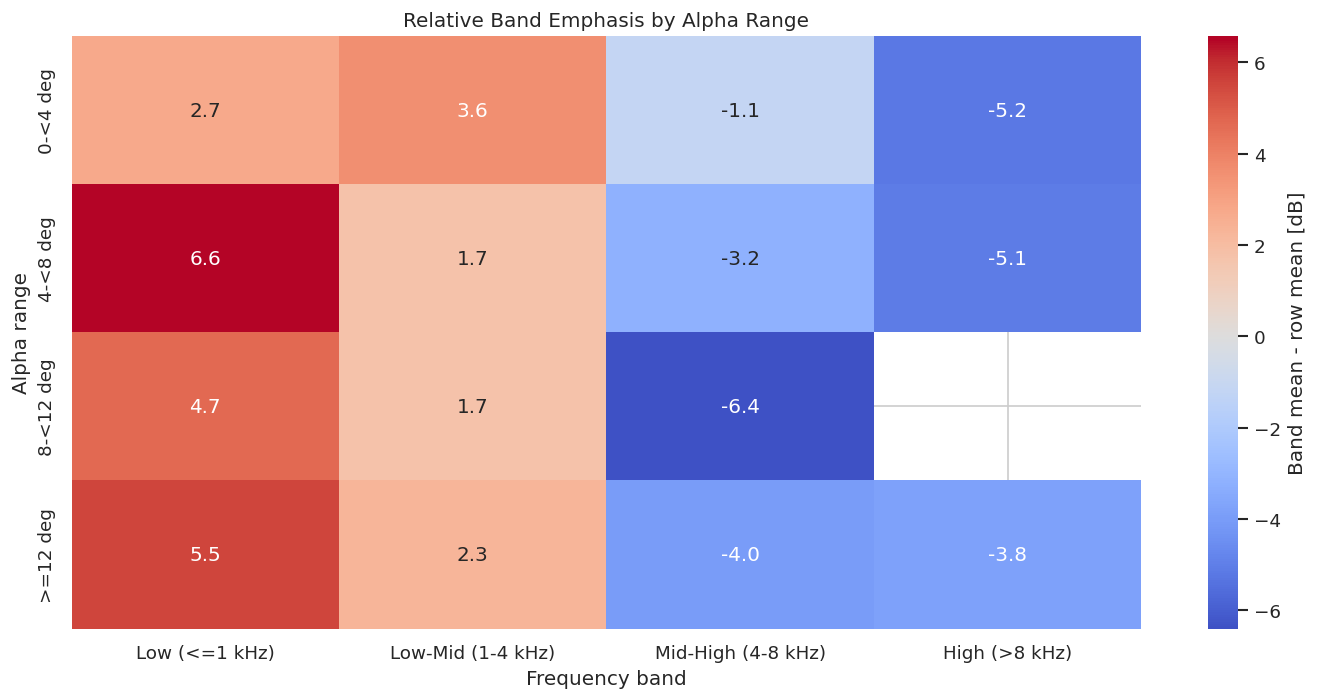

In [60]:
plot_median_spectrum(
    df,
    group_col='alpha_group',
    title='Median Spectrum by Alpha Range'
)

plot_relative_band_heatmap(
    df,
    index_col='alpha_group',
    ylabel='Alpha range',
    title='Relative Band Emphasis by Alpha Range',
    figsize=(12, 6)
)


### 6.4 Boundary-layer Thickness (`delta`)


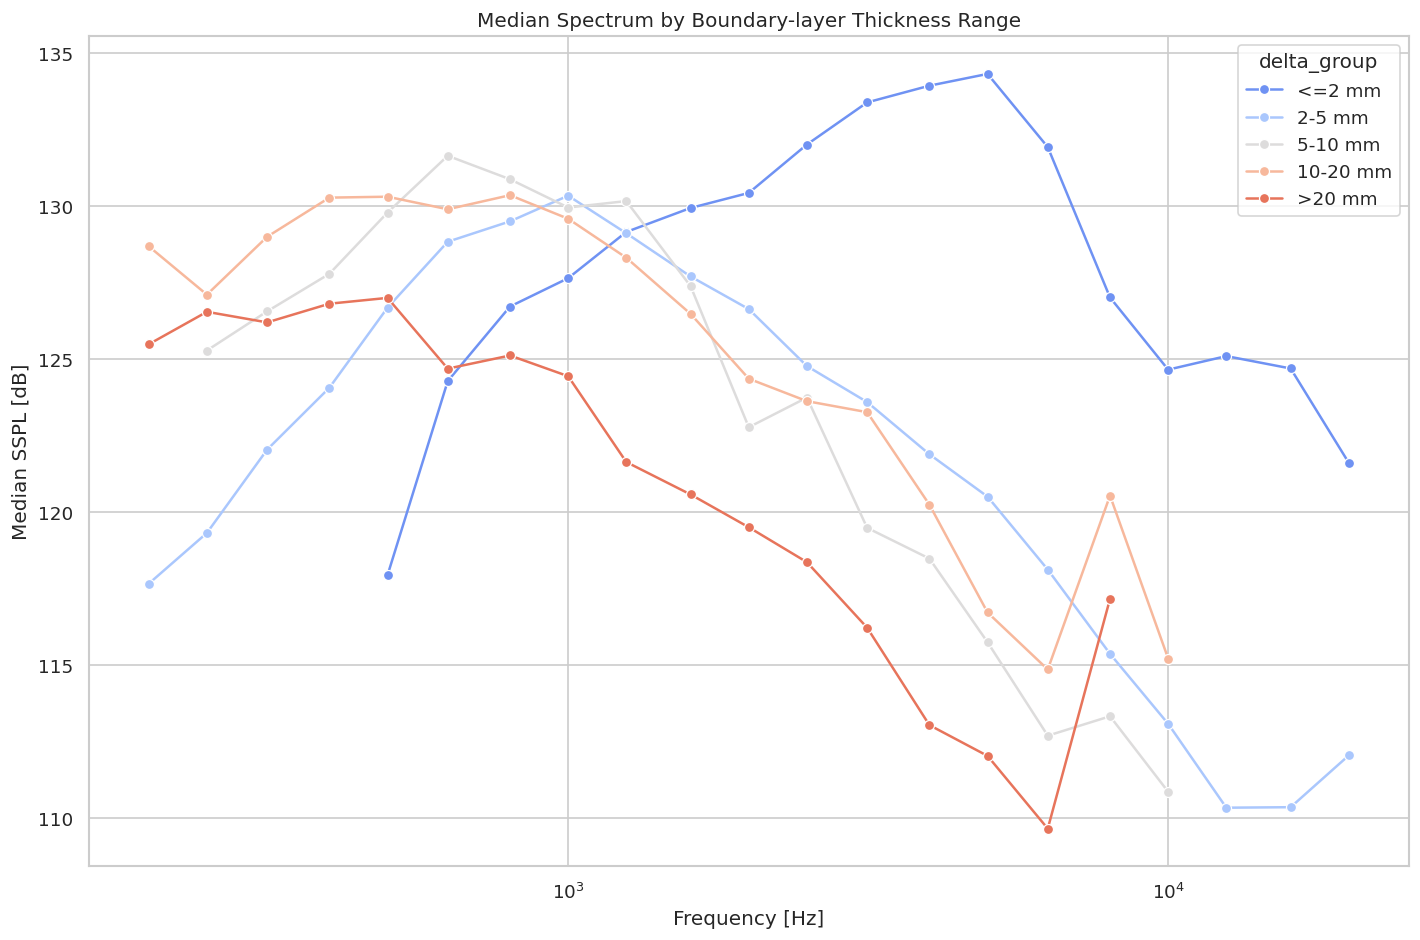

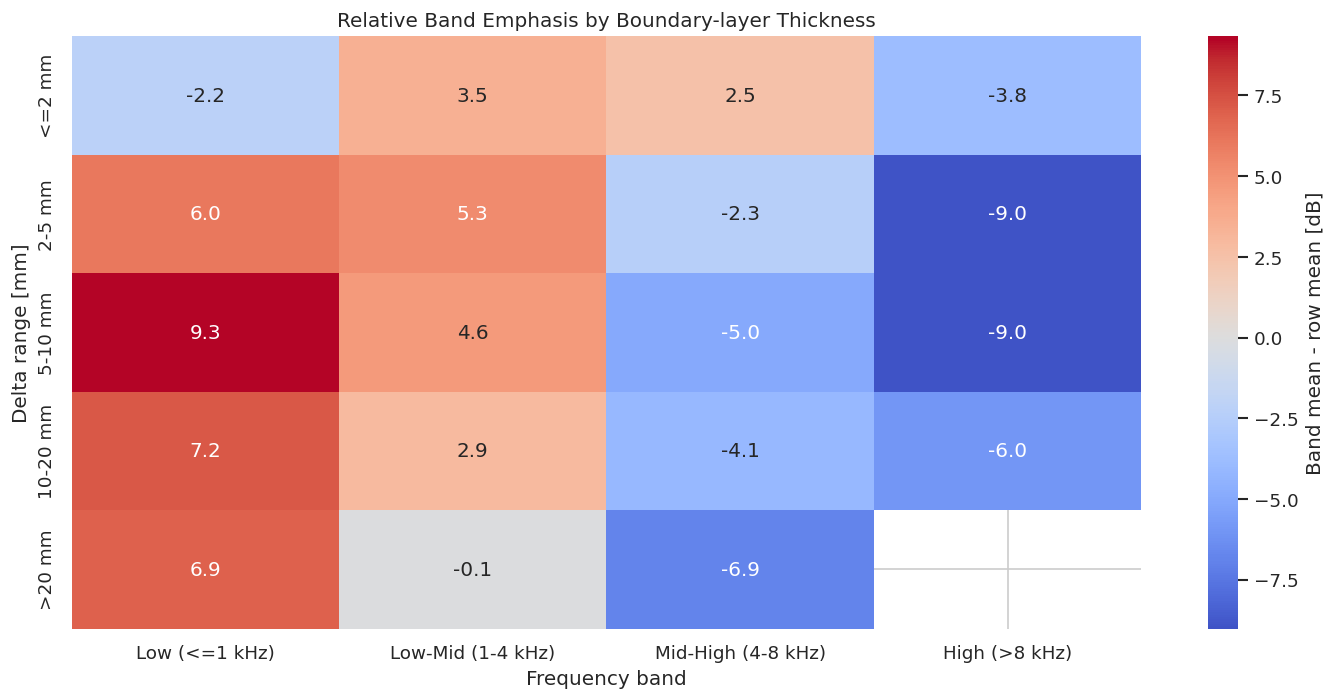

In [61]:
plot_median_spectrum(
    df,
    group_col='delta_group',
    title='Median Spectrum by Boundary-layer Thickness Range'
)

plot_relative_band_heatmap(
    df,
    index_col='delta_group',
    ylabel='Delta range [mm]',
    title='Relative Band Emphasis by Boundary-layer Thickness',
    figsize=(12, 6)
)


## 7. Dominant Band by Operating Condition


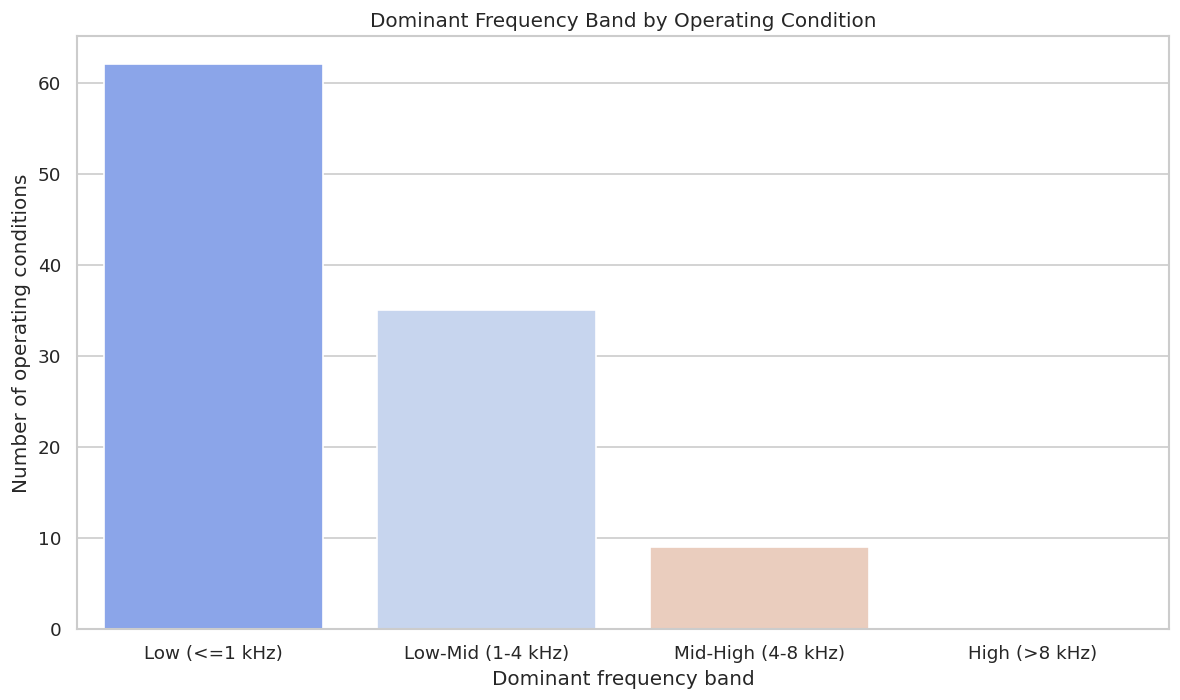

In [62]:
dominant_band = (
    df.groupby(['condition_id', 'frequency_band'], observed=False)['SSPL']
    .mean()
    .reset_index()
)
dominant_band = dominant_band.loc[
    dominant_band.groupby('condition_id')['SSPL'].idxmax()
].reset_index(drop=True)

dominant_band_summary = (
    dominant_band['frequency_band']
    .value_counts()
    .reindex(frequency_band_labels, fill_value=0)
    .rename_axis('dominant_band')
    .reset_index(name='condition_count')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=dominant_band_summary,
    x='dominant_band',
    y='condition_count',
    hue='dominant_band',
    dodge=False,
    palette='coolwarm',
    legend=False
)
plt.xlabel('Dominant frequency band')
plt.ylabel('Number of operating conditions')
plt.title('Dominant Frequency Band by Operating Condition')
plt.tight_layout()
plt.show()


## 8. Exploratory Strouhal-number Scaling

These plots are exploratory. `St_c = fc/U_infinity` uses chord length as
the characteristic length scale, while `St_delta = f delta/U_infinity`
uses the suction-side displacement thickness provided by the dataset.


In [63]:
df['St_delta'] = df['f'] * df['delta'] / df['U_infinity']
df['St_c'] = df['f'] * df['c'] / df['U_infinity']


def summarize_strouhal_trend(data, st_col, q=10):
    bin_col = f'{st_col}_bin'
    data = data.copy()
    data[bin_col] = pd.qcut(data[st_col], q=q, duplicates='drop')

    return (
        data.groupby(['frequency_band', bin_col], observed=False)
        .agg(
            St_mid=(st_col, 'median'),
            median_SSPL=('SSPL', 'median'),
            sample_count=('SSPL', 'size')
        )
        .reset_index()
    )


st_delta_summary = summarize_strouhal_trend(df, 'St_delta')
st_c_summary = summarize_strouhal_trend(df, 'St_c')


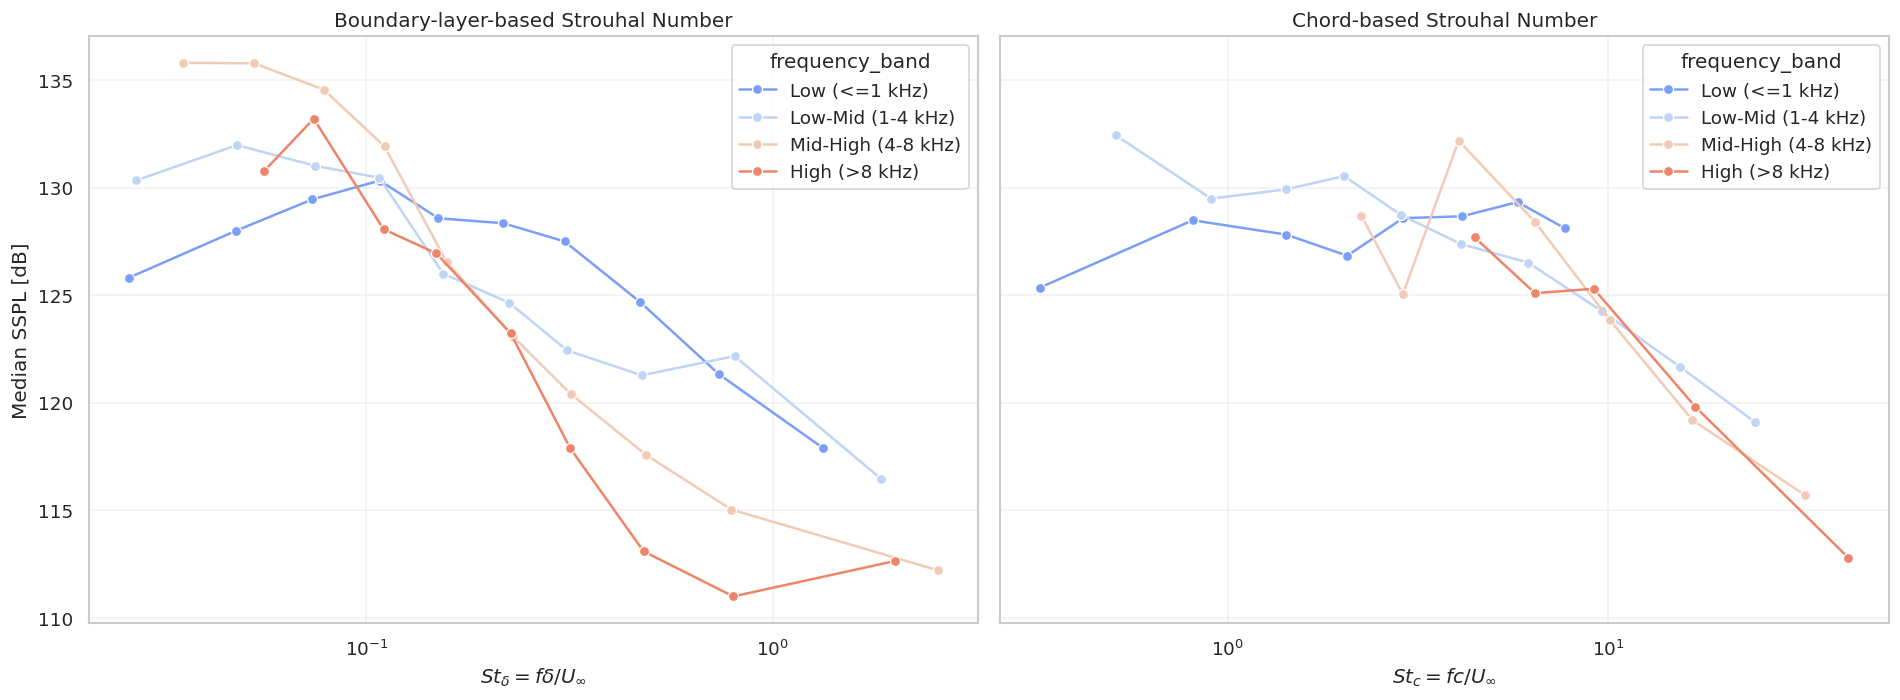

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_specs = [
    (
        axes[0],
        st_delta_summary,
        'Boundary-layer-based Strouhal Number',
        r'$St_\delta = f\delta/U_\infty$'
    ),
    (
        axes[1],
        st_c_summary,
        'Chord-based Strouhal Number',
        r'$St_c = fc/U_\infty$'
    )
]

for ax, summary, title, xlabel in plot_specs:
    sns.lineplot(
        data=summary,
        x='St_mid',
        y='median_SSPL',
        hue='frequency_band',
        marker='o',
        palette='coolwarm',
        ax=ax
    )
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median SSPL [dB]')
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## 9. Regression Modeling

Linear Regression, Random Forest Regression, and Support Vector Regression
(SVR) are compared as supervised predictors of `SSPL`. To avoid optimistic
evaluation, operating-condition groups are split with `GroupShuffleSplit`, so
the same `(alpha, c, U_infinity, delta)` condition does not appear in both
train and test sets.


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR

feature_cols = ['f', 'alpha', 'c', 'U_infinity', 'delta']
target_col = 'SSPL'

X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[condition_cols].astype(str).agg(' | '.join, axis=1)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train groups:", groups_train.nunique())
print("Test groups:", groups_test.nunique())
print("Shared groups:", len(set(groups_train) & set(groups_test)))


Train shape: (1188, 5)
Test shape: (315, 5)
Train groups: 84
Test groups: 22
Shared groups: 0


In [66]:
linear_model = Pipeline(
    steps=[
        ('scaler', MinMaxScaler()),
        ('model', LinearRegression())
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

svm_model = Pipeline(
    steps=[
        ('scaler', MinMaxScaler()),
        ('model', SVR(kernel='rbf', C=100, epsilon=0.5, gamma='scale'))
    ]
)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)


In [67]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE [dB]': mean_absolute_error(y_true, y_pred),
        'RMSE [dB]': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred)
    }


metrics_df = pd.DataFrame(
    [
        {'Model': 'Linear Regression', **regression_metrics(y_test, linear_pred)},
        {'Model': 'Random Forest', **regression_metrics(y_test, rf_pred)},
        {'Model': 'SVM Regression', **regression_metrics(y_test, svm_pred)}
    ]
)

display(metrics_df)


,Model,MAE [dB],RMSE [dB],R2
0,Linear Regression,3.997943,5.183942,0.375326
1,Random Forest,1.867720,2.622918,0.840080
2,SVM Regression,2.830216,4.043486,0.619946


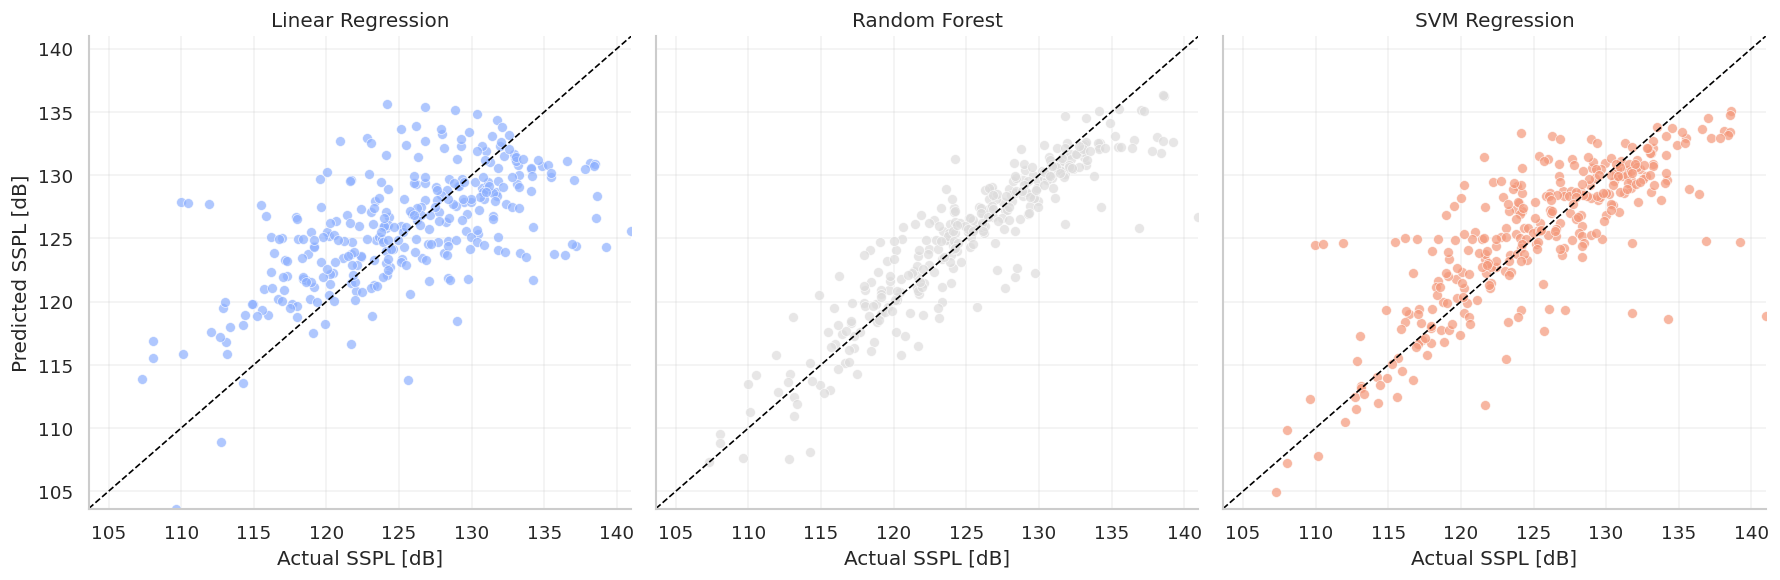

In [68]:
plot_df = pd.DataFrame(
    {
        'Actual SSPL [dB]': np.concatenate([y_test.values, y_test.values, y_test.values]),
        'Predicted SSPL [dB]': np.concatenate([linear_pred, rf_pred, svm_pred]),
        'Model': (
            ['Linear Regression'] * len(y_test)
            + ['Random Forest'] * len(y_test)
            + ['SVM Regression'] * len(y_test)
        )
    }
)

min_val = min(plot_df['Actual SSPL [dB]'].min(), plot_df['Predicted SSPL [dB]'].min())
max_val = max(plot_df['Actual SSPL [dB]'].max(), plot_df['Predicted SSPL [dB]'].max())

g = sns.FacetGrid(
    plot_df,
    col='Model',
    hue='Model',
    palette='coolwarm',
    height=5,
    aspect=1
)
g.map_dataframe(
    sns.scatterplot,
    x='Actual SSPL [dB]',
    y='Predicted SSPL [dB]',
    alpha=0.7,
    s=35
)

for ax in g.axes.flat:
    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.25)

g.set_titles('{col_name}')
plt.tight_layout()
plt.show()


/tmp/ipykernel_8800/1156608972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


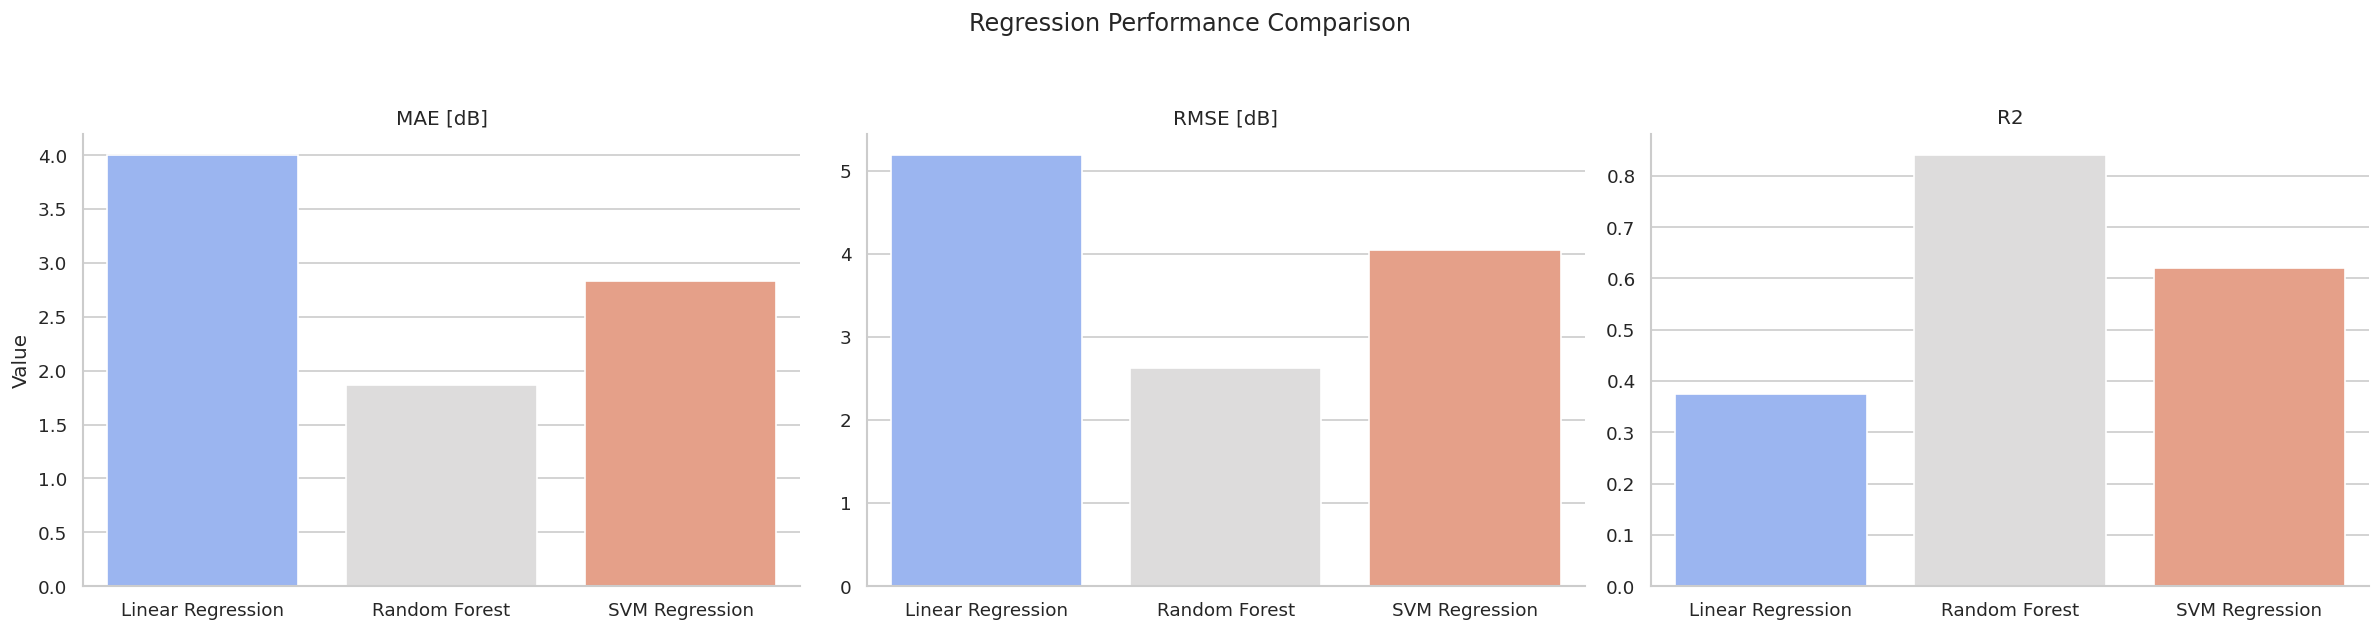

In [69]:
comparison_plot_df = metrics_df.melt(
    id_vars='Model',
    value_vars=['MAE [dB]', 'RMSE [dB]', 'R2'],
    var_name='Metric',
    value_name='Value'
)

g = sns.catplot(
    data=comparison_plot_df,
    x='Model',
    y='Value',
    col='Metric',
    kind='bar',
    sharey=False,
    palette='coolwarm',
    height=5,
    aspect=1.3
)

g.set_axis_labels('', 'Value')
g.set_titles('{col_name}')
g.fig.suptitle('Regression Performance Comparison', y=1.05)
g.fig.set_size_inches(20, 5)
plt.tight_layout()
plt.show()


,Feature,Importance
0,delta,0.425931
1,f,0.390827
2,c,0.094674
3,alpha,0.044452
4,U_infinity,0.044116


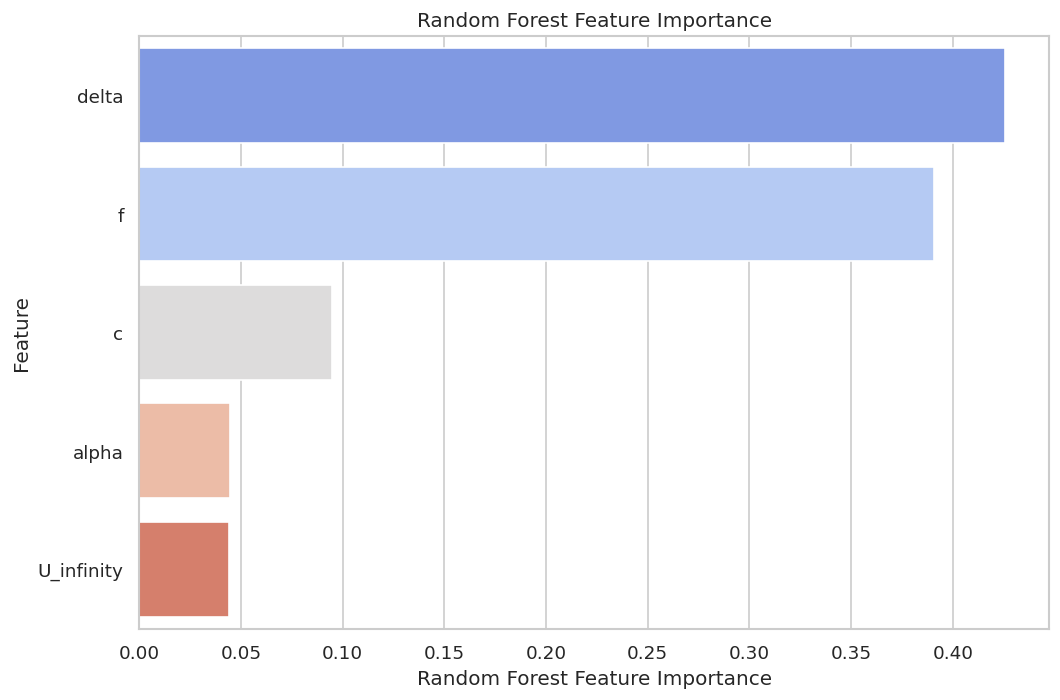

In [70]:
feature_importance_df = (
    pd.DataFrame(
        {
            'Feature': feature_cols,
            'Importance': rf_model.feature_importances_
        }
    )
    .sort_values(by='Importance', ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    dodge=False,
    palette='coolwarm',
    legend=False
)
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
